In [71]:
%load_ext autoreload
%autoreload 2

import os
import sys

# Get project root relative to the notebook file
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() \
                else os.getcwd()

project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
src_path = os.path.join(project_root, "src")

print("Adding to path:", src_path)
sys.path.insert(0, "/home/wallace/Projects/ncpu/src")

import torch
from ncpu.runner  import TrainRunnerUI, setup_trainer
from ncpu.config import BIG_CONJUNCTION_TRAINING_CONFIG
import mediapy as media

Adding to path: /home/wallace/Projects/ncpu/src


In [72]:
# TrainRunnerUI(BIG_CONJUNCTION_TRAINING_CONFIG).render()

In [74]:
trainer = setup_trainer(BIG_CONJUNCTION_TRAINING_CONFIG)

Sanity check...
  forward: torch.Size([2, 16, 117, 117]) -> torch.Size([2, 11, 16, 117, 117])
  dataloader: torch.Size([16, 117, 117]) -> torch.Size([16, 117, 117])
  first_state: torch.Size([16, 16, 117, 117])
  rollout: torch.Size([16, 11, 16, 117, 117])
  loss: 0.46608132123947144
Sanity check completed successfully


In [78]:
state_dict = torch.load("notebooks/checkpoints/ncpu_127580_20251130_203719.pth")
trainer.nca.load_state_dict(state_dict)

<All keys matched successfully>

loss=0.195880:   3%|2         | 5250/200000 [05:40<3:15:07, 16.64it/s]

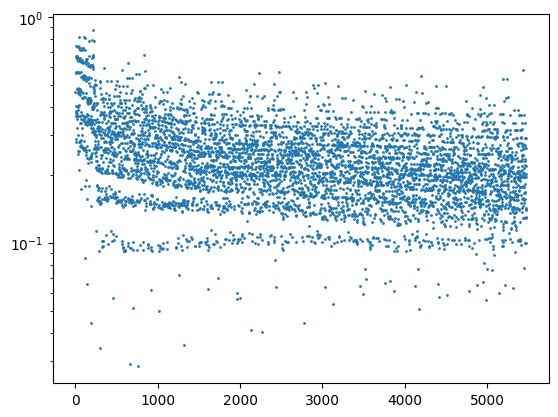

inp    : (16, 117, 117) torch.float32, min=0.00, max=1.00, mean=0.13, std=0.34
out    : (16, 117, 117) torch.float32, min=0.00, max=1.00, mean=0.03, std=0.16
nca_out: (16, 117, 117) torch.float32, min=-0.18, max=0.66, mean=0.17, std=0.15


,,,,,,,
,,,,,,,
,,,,,,,

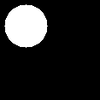
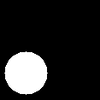
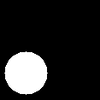
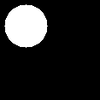
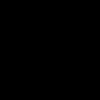
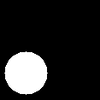
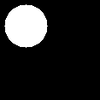
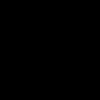
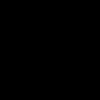
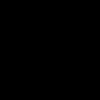
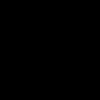
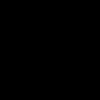
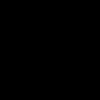
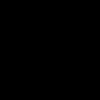
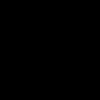
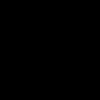
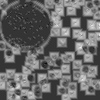
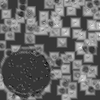
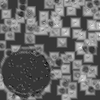
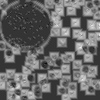
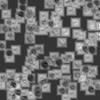
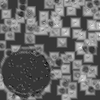
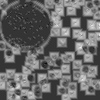
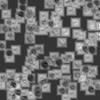

#0,#1,#2,#3,#4,#5,#6,#7

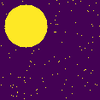
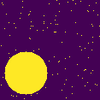
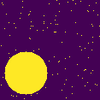
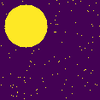
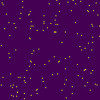
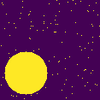
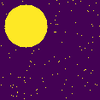
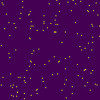

#0,#1,#2,#3,#4,#5,#6,#7

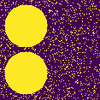
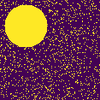
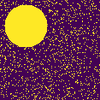
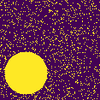
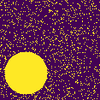
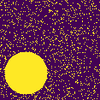
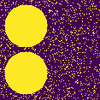
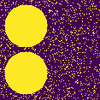

KeyboardInterrupt: 

In [ ]:
from matplotlib import pyplot as plt
from IPython.display import clear_output, display
from tqdm.auto import tqdm
from datetime import datetime
from ncpu.utils import print_tensor, sequence_batch_to_html_gifs

pbar = tqdm(range(200_000))
for i in pbar:
    info = trainer.optim_step()
    loss = info["loss"].item()
    pbar.set_description(f"loss={loss:.6f}")

    if i % 250 == 0:
        clear_output(wait=False)
        display(pbar.container)
        plt.scatter(range(len(trainer.history)), trainer.history, s=1)
        plt.yscale("log")
        plt.show()

        print_tensor("inp    ", info["inp"])
        print_tensor("out    ", info["out"])
        print_tensor("nca_out", info["nca_out"])

        to_show = 8
        inp = info["inp"][:to_show]
        out = info["out"][:to_show]
        nca_out = info["nca_out"][:to_show]
        rollout = info["rollout"][:to_show]
        io = torch.cat([inp, out, nca_out], dim=0)

        media.show_images(io.detach().cpu(), columns=to_show, width=100, height=100)
        sequence_batch_to_html_gifs(rollout, columns=to_show, fps=10)

        it = len(trainer.history)

        checkpoint_dir = "checkpoints"
        if not os.path.isdir(checkpoint_dir):
            os.makedirs(checkpoint_dir, exist_ok=True)
        path = f"{checkpoint_dir}/ncpu_{it}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(trainer.nca.state_dict(), path)